In [3]:
import pandas as pd
import numpy as np

# Load cleaned source data
df = pd.read_csv("../data/data_cleaned.csv")

# 1) Fix shifted rows: force numeric for age and duration_minutes
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["duration_minutes"] = pd.to_numeric(df["duration_minutes"], errors="coerce")

# 2) Ensure weight_kg is numeric (for later outlier filter)
df["weight_kg"] = pd.to_numeric(df["weight_kg"], errors="coerce")

# 3) Drop rows with any NaN produced above (broken/shifted rows)
df = df.dropna(subset=["age", "duration_minutes", "weight_kg"])

# 4) Fix fake exercises: keep only string exercise_type values with no digits
mask_is_str = df["exercise_type"].apply(lambda x: isinstance(x, str))
mask_no_digits = ~df.loc[mask_is_str, "exercise_type"].str.contains(r"\d", regex=True)
valid_exercise_indices = df.loc[mask_is_str].loc[mask_no_digits].index
df = df.loc[valid_exercise_indices]

# 5) Fix weight outliers: keep only rows where weight_kg < 150
df = df[df["weight_kg"] < 150]

# 6) Clean index
df = df.reset_index(drop=True)

# 7) Save final ML-ready dataset and print shape
output_path = "../data/data_ready_v1.csv"
df.to_csv(output_path, index=False)
print("Final dataset shape:", df.shape)

Final dataset shape: (2183, 12)


In [4]:
# Drop the columns: user_id, workout_id, and exercise_order
df = df.drop(columns=["user_id", "workout_id", "exercise_order"])

# Remove duplicates and print how many rows were dropped
orig_rows = len(df)
df = df.drop_duplicates()
rows_dropped = orig_rows - len(df)
print(f"Rows dropped as duplicates: {rows_dropped}")

# Create BMI column
df["BMI"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)

# Print new shape and head
print("After processing:", df.shape)
print(df.head())

Rows dropped as duplicates: 941
After processing: (1242, 10)
    age sex  height_cm  weight_kg      exercise_type  duration_minutes  \
0  28.0   M      182.0         82            walking              20.0   
1  28.0   M      182.0         82  strength training              45.0   
2  28.0   M      182.0         82     stair climbing              15.0   
3  34.0   F      162.0         58               yoga              30.0   
4  34.0   F      162.0         58            pilates              25.0   

  intensity_level  avg_heart_rate  calories_burned        BMI  
0             low            95.0               80  24.755464  
1        moderate           122.0              315  24.755464  
2            high           158.0              150  24.755464  
3             low            92.0               90  22.100290  
4        moderate           115.0              110  22.100290  


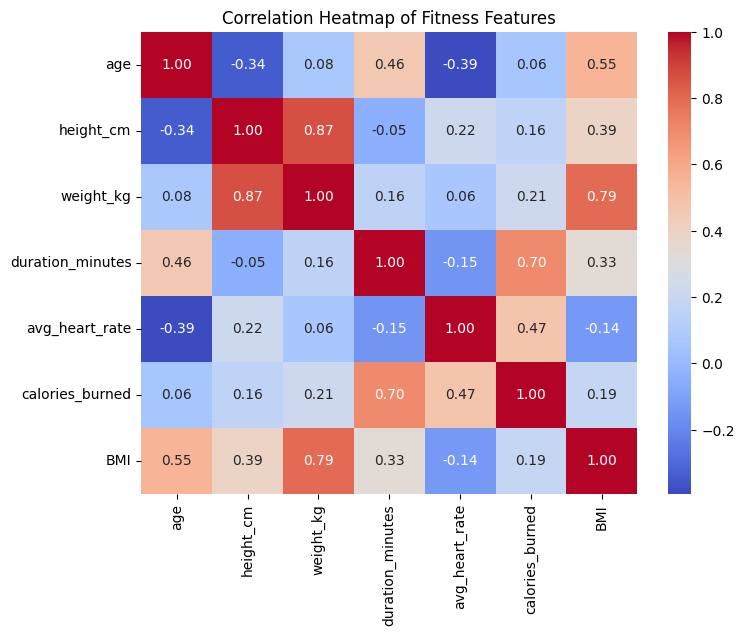

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns likely to be correlated (numerical, relevant for fitness data)
corr_cols = [
    "age",
    "height_cm",
    "weight_kg",
    "duration_minutes",
    "avg_heart_rate",
    "calories_burned",
    "BMI"
]
df_corr = df[corr_cols]

# Compute the correlation matrix
corr_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Fitness Features")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Drop height_cm (high multicollinearity with weight)
df = df.drop(columns=["height_cm"])  # BMI already captures height/weight relationship

# 2) Map sex: 'M' -> 0, 'F' -> 1
sex_map = {"M": 0, "F": 1}
df["sex"] = df["sex"].map(sex_map)

# 3) Map intensity_level: 'low' -> 1, 'moderate' -> 2, 'high' -> 3
intensity_map = {"low": 1, "moderate": 2, "high": 3}
df["intensity_level"] = df["intensity_level"].map(intensity_map)

# 4) One-hot encode exercise_type with integer dummies
df = pd.get_dummies(df, columns=["exercise_type"], dtype=int)

# 5) Define features X and target y
X = df.drop(columns=["calories_burned"])
y = df["calories_burned"].copy()

# 6) Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7) Scale ONLY continuous numeric columns
numeric_cols = ["age", "weight_kg", "duration_minutes", "avg_heart_rate"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 8) Print shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (993, 23)
X_test shape: (249, 23)
y_train shape: (993,)
y_test shape: (249,)


In [ ]:
import json
from pathlib import Path
import joblib

# Directory to store preprocessing artifacts
artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# 1) Save the fitted StandardScaler
scaler_path = artifacts_dir / "standard_scaler.pkl"
joblib.dump(scaler, scaler_path)

# 2) Save preprocessing metadata needed to reproduce the pipeline
preprocess_metadata = {
    "numeric_cols": numeric_cols,
    "all_feature_cols": list(X.columns),
    "sex_map": sex_map,
    "intensity_map": intensity_map,
}

metadata_path = artifacts_dir / "preprocessing_metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(preprocess_metadata, f, indent=2)

X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

print("Saved scaler, preprocessing metadata, and train/test splits.")